In [2]:
import pandas as pd

In [3]:
dfraw = pd.read_csv('/home/pawel/projects/doktorat/data/combined_emotion.csv')
dfraw.head()

,sentence,emotion
0,i just feel really helpless and heavy hearted,fear
1,ive enjoyed being able to slouch about relax a...,sad
2,i gave up my internship with the dmrg and am f...,fear
3,i dont know i feel so lost,sad
4,i am a kindergarten teacher and i am thoroughl...,fear


In [4]:
dfraw['emotion'].value_counts()

emotion
joy        143067
sad        121187
anger       59317
fear        49649
love        34554
suprise     14972
Name: count, dtype: int64

In [5]:
# take sample of 10000 rows for each emotion
df = dfraw.groupby('emotion').apply(lambda x: x.sample(n=10000, random_state=42)).reset_index(drop=True)
df

/tmp/ipykernel_109357/3093109635.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = dfraw.groupby('emotion').apply(lambda x: x.sample(n=10000, random_state=42)).reset_index(drop=True)


,sentence,emotion
0,i am feeling tortured,anger
1,i drink a full cup of coffee i become what i f...,anger
2,i know people have already given her hell for ...,anger
3,i feel sickened by and disgusted with the sins...,anger
4,i havent worked out today but i feel like im j...,anger
...,...,...
59995,i came home this morning at around feeling dazed,suprise
59996,i feel funny with the,suprise
59997,i say it feels kinda weird,suprise
59998,i always feel a title see also how to be funny...,suprise


In [5]:
from sentence_transformers import SentenceTransformer

vectorizer = SentenceTransformer('all-MiniLM-L6-v2')
# create embeddings for each sentence

2025-06-04 20:37:29.653288: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-04 20:37:29.768086: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-04 20:37:29.800880: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-04 20:37:30.002820: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-06-04 20:37:31.997590: W tensorflow/compiler/tf2

In [30]:
vectors = vectorizer.encode(df['sentence'].tolist(), show_progress_bar=True, device='cuda')

Batches:   0%|          | 0/1875 [00:00<?, ?it/s]

In [52]:
vectorizer.parameters

<bound method Module.parameters of SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False}) with Transformer model: BertModel 
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)>

In [31]:

import matplotlib.pyplot as plt
def plot_history(history):
    # plot training & validation accuracy values and loss values
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='train_accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [7]:
emotions = df['emotion'].unique().tolist()
# encode emotions as target labels for softmax layer
emotion_labels = {emotion: idx for idx, emotion in enumerate(emotions)}
# map emotions to their corresponding indices
emotion_target = df['emotion'].map(emotion_labels).tolist()
emotion_labels

{'anger': 0, 'fear': 1, 'joy': 2, 'love': 3, 'sad': 4, 'suprise': 5}

In [8]:
# encode emotions as one-hot vectors
from tensorflow.keras.utils import to_categorical
emotion_target_one_hot = to_categorical(emotion_target, num_classes=len(emotions))

In [69]:
emotion_target_one_hot

array([[1., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.]])

In [32]:
# create train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(vectors, emotion_target_one_hot, test_size=0.2, random_state=42)

X_train.shape, y_train.shape, X_test.shape, y_test.shape


((48000, 384), (48000, 6), (12000, 384), (12000, 6))

In [74]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((48000, 384), (48000, 6), (12000, 384), (12000, 6))

In [82]:
# create neural network model in keras to classify emotions
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input

model = Sequential()

model.add(Input(shape=(384,)))  # 384 is the size of the embeddings
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))  # add dropout to prevent overfitting
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
# adjust the output layer to match the one hot encoded vector of emotions
model.add(Dense(6, activation='softmax'))  # 6 emotions

model.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 512)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369,990 (1.41 MB)

 Trainable params: 369,990 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

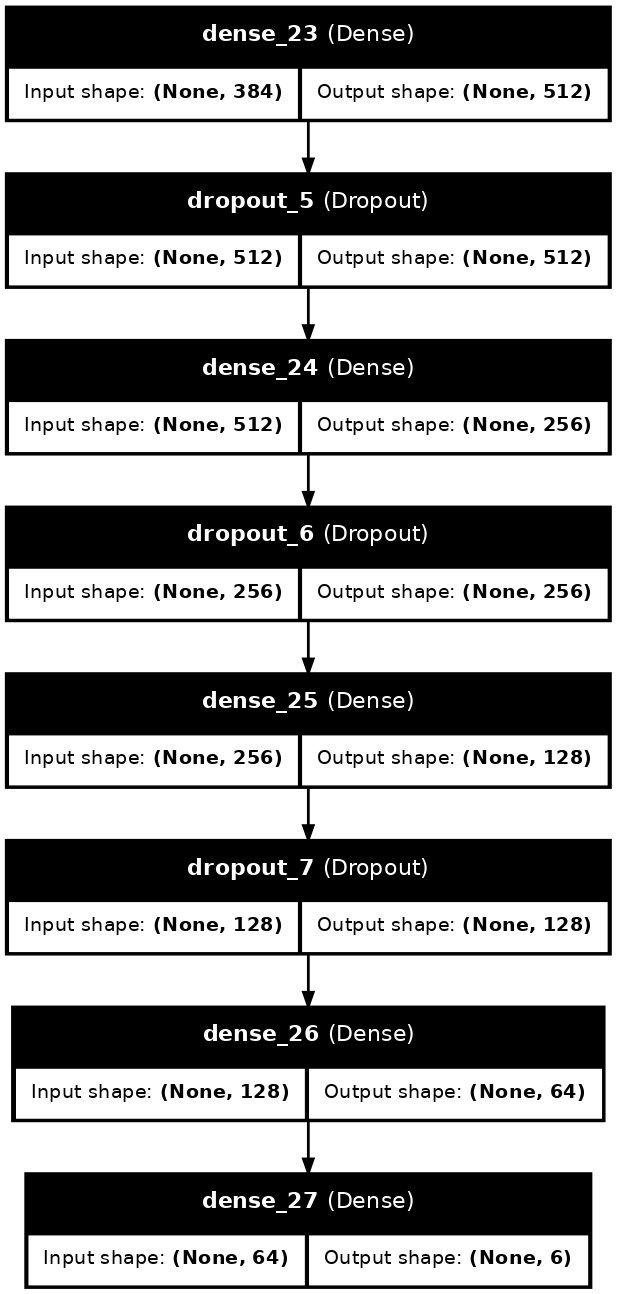

In [83]:
# plot model architecture
from keras.utils import plot_model

plot_model(model, show_shapes=True, show_layer_names=True,  dpi=100)

In [84]:
# train the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))
# evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss: {loss}, Accuracy: {accuracy}')


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.5392 - loss: 1.1962 - val_accuracy: 0.7170 - val_loss: 0.7911
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7211 - loss: 0.7800 - val_accuracy: 0.7375 - val_loss: 0.7209
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7593 - loss: 0.6625 - val_accuracy: 0.7546 - val_loss: 0.6843
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7885 - loss: 0.5913 - val_accuracy: 0.7584 - val_loss: 0.6602
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8066 - loss: 0.5356 - val_accuracy: 0.7668 - val_loss: 0.6563
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8277 - loss: 0.4810 - val_accuracy: 0.7672 - val_loss: 0.6597
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8389 - loss: 0.4469 - val_accuracy: 0.7713 - val_loss: 0.6540
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8460 - loss: 0.4149 

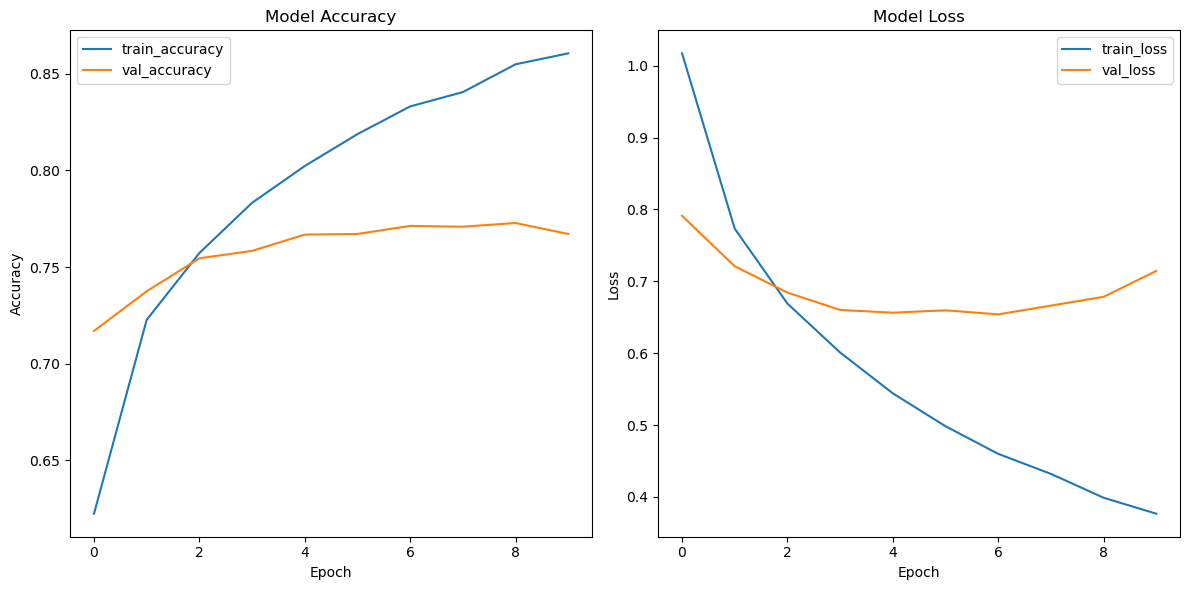

In [85]:
plot_history(history)

### Wektoryzacja modelem transformers aby uzyskać pełnowymiarowe wektorym

In [ ]:
vectors_lstm = vectorizer.encode(df['sentence'].tolist(), show_progress_bar=True, device='cuda', output_value='token_embeddings', normalize_embeddings=False, convert_to_numpy=True, precision='int8')

Batches:   0%|          | 0/1875 [00:00<?, ?it/s]

In [25]:
from keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import torch
# --- 3. Determine the embedding dimension and a suitable max_sequence_length ---
# The embedding dimension is consistent across all tokens for a given model.
embedding_dim = vectors_lstm[0].shape[1]

# Choose a max_sequence_length.
# A good heuristic is to look at the distribution of token lengths in your data.
# You can also use the SBERT model's internal max_seq_length.
# For 'all-MiniLM-L6-v2', it's often 256 or 128. Let's use 64 for demonstration.
max_sequence_length = 64
print(f"Embedding dimension: {embedding_dim}")
print(f"Chosen max sequence length for padding: {max_sequence_length}")

vectors_lstm_list_cpu_np = []
for token_embedding_tensor in vectors_lstm:
    if isinstance(token_embedding_tensor, torch.Tensor):
        vectors_lstm_list_cpu_np.append(token_embedding_tensor.cpu().numpy())
    else:
        # If for some reason it's already a NumPy array (e.g., on CPU), just append
        vectors_lstm_list_cpu_np.append(token_embedding_tensor)

# --- 4. Pad/Truncate the token embeddings to a consistent shape ---
# pad_sequences expects a list of 2D arrays and returns a single 3D array.
padded_vectors_lstm = pad_sequences(
    vectors_lstm_list_cpu_np,
    maxlen=max_sequence_length,
    dtype='float32',
    padding='post',    # Pad with zeros after the sequence
    truncating='post'  # Truncate from the end if sequence is too long
)

print(f"Shape of padded_vectors_lstm: {padded_vectors_lstm.shape}")
# Expected shape: (num_samples, max_sequence_length, embedding_dim)

# --- 5. Perform the train-test split with the padded embeddings ---
X_train, X_test, y_train, y_test = train_test_split(
    padded_vectors_lstm,
    emotion_target_one_hot,
    test_size=0.2,
    random_state=42
)

Embedding dimension: 384
Chosen max sequence length for padding: 64
Shape of padded_vectors_lstm: (60000, 64, 384)


In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    padded_vectors_lstm,
    emotion_target_one_hot,
    test_size=0.2,
    random_state=42)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((48000, 64, 384), (48000, 6), (12000, 64, 384), (12000, 6))

In [44]:
# now build lstm model processing the vectors as sequences

from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input

model_lstm = Sequential()
model_lstm.add(Input(shape=(64, 384)))
model_lstm.add(LSTM(64, return_sequences=True))
model_lstm.add(LSTM(32, return_sequences=False))
model_lstm.add(Dropout(0.3))
model_lstm.add(Dense(16, activation='relu'))
model_lstm.add(Dense(6, activation='softmax'))  # 6 emotions
model_lstm.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64, 64)         │       114,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,990 (499.96 KB)

 Trainable params: 127,990 (499.96 KB)

 Non-trainable params: 0 (0.00 B)

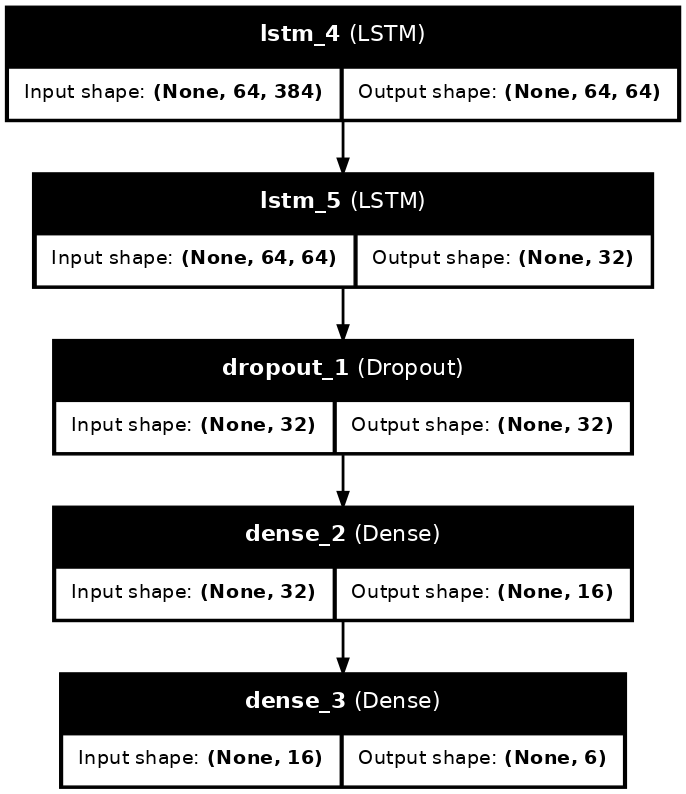

In [45]:
plot_model(model_lstm, show_shapes=True, show_layer_names=True,  dpi=100)

In [ ]:
# compile and train the model
model_lstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm_history = model_lstm.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))
# evaluate the model
#loss_lstm, accuracy_lstm = model_lstm.evaluate(X_test, y_test)
#print(f'LSTM Loss: {loss_lstm}, Accuracy: {accuracy_lstm}')

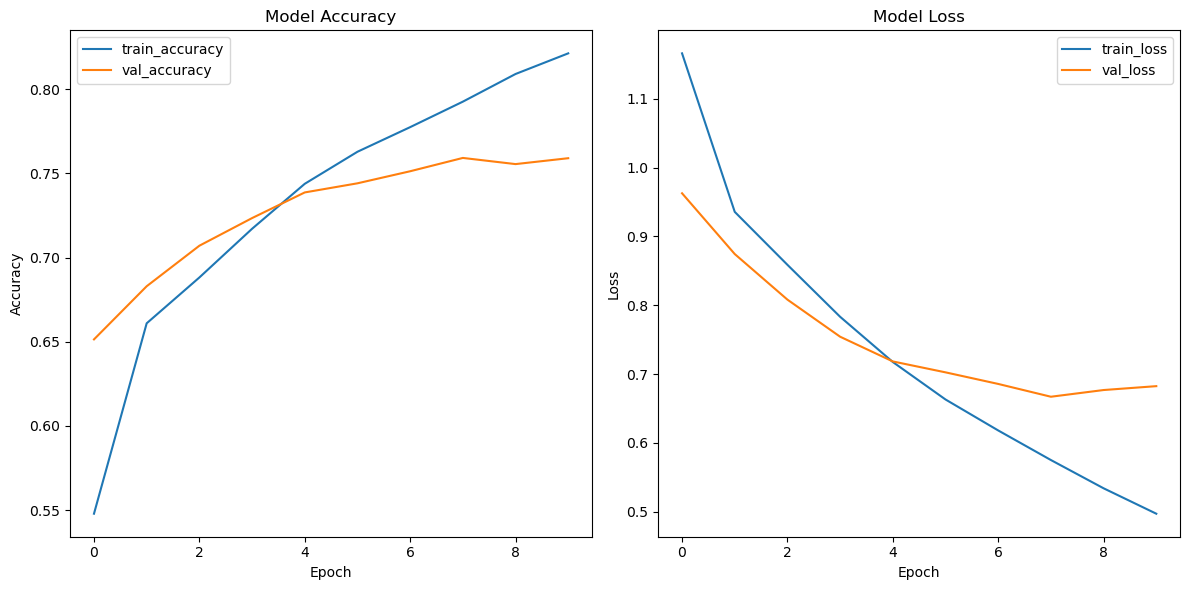

In [109]:
# plot the training history

plot_history(lstm_history)  

In [ ]:
# predict with the model on new sentence

def predict_emotion(sentence, model_type='dense'):
    vector = vectorizer.encode([sentence], show_progress_bar=False, device='cuda')
    if model_type == 'lstm':
        vector = vector.reshape(-1, 1, 384)
        predictor = model_lstm
    else:
        predictor = model
        vector = vector.reshape(-1, 384)
    
    prediction = predictor.predict(vector)
    emotion_index = prediction.argmax(axis=1)[0]
    emotion = emotions[emotion_index]
    return emotion 

predict_emotion("The day is very nice", model_type='dense')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
[[1.18785715e-06 2.78500835e-07 1.11874826e-01 8.87822330e-01
  2.88803916e-04 1.25331962e-05]]


'love'